# RQ1 --- Effectiveness

In [51]:
import sys; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
from analysis._loader import load_all_results, success_only
from analysis._analysis import ( PALETTE, tex,
    compute_image_metrics, compute_text_metrics, SPLIT_LABEL, SPLIT_ORDER
)
import matplotlib as mpl
mpl.rcParams.update(
        {
            "text.usetex": True,
            "text.latex.preamble": r"\usepackage{amsmath}",
            "font.family": "serif",
            "font.size": 20,
            "axes.titlesize": 22,
            "axes.labelsize": 20,
            "xtick.labelsize": 20,
            "ytick.labelsize": 16,
            "legend.fontsize": 16,
            "legend.title_fontsize": 16,
            "figure.titlesize": 22,
        }
    )

df_all = load_all_results(include_baseline_fail=True)
df_opt = success_only(df_all)

THRESHOLDS = np.arange(0.0, 1.1, 0.1)   # 0.0, 0.1, ..., 0.9

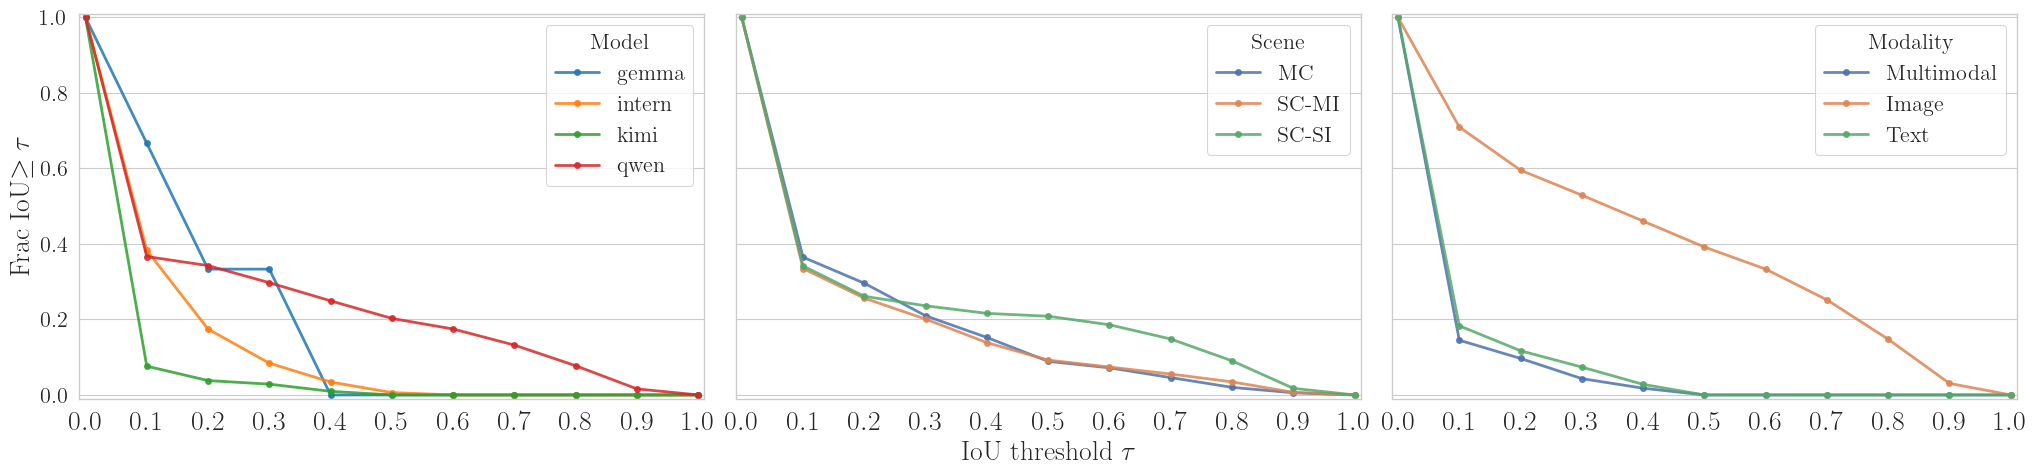

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5), sharey=True)
fig.subplots_adjust(wspace=0.05)

# 1) By model
ax = axes[0]
for i, model in enumerate(sorted(df_opt['model'].unique())):
    sub = df_opt[df_opt['model'] == model]
    ax.plot(
        THRESHOLDS,
        [(sub['final_iou'] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=tex(model),
        color=PALETTE[i],
        alpha=0.85,
        marker='o',
        markersize=4,
    )
##ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_ylabel(r'Frac IoU$\geq\tau$', fontsize=20)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title='Model')
ax.grid(axis='x')

# 2) By scene
SCENE_ALIAS = {
    'multi': 'MC',
    'single/multi': 'SC-MI',
    'single/solo': 'SC-SI',
}

ax = axes[1]
for scene, label in SCENE_ALIAS.items():
    sub = df_opt[df_opt['obj_category'] == scene]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub['final_iou'] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker='o',
        markersize=4,
    )
ax.set_xlabel(r'IoU threshold $\tau$', fontsize=20)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title='Scene')
ax.grid(axis='x')

# 3) By modality
MODALITY_ALIAS = {
    'multi': 'Multimodal',
    'image': 'Image',
    'text': 'Text',
}

ax = axes[2]
for modality, label in MODALITY_ALIAS.items():
    sub = df_opt[df_opt['genome_mode'] == modality]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub['final_iou'] >= t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker='o',
        markersize=4,
    )
#ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title='Modality')
ax.grid(axis='x')
plt.savefig("figures/curves_rq1.pdf", dpi=200, bbox_inches='tight')

In [ ]:
df_opt = compute_image_metrics(df_opt)
df_txt = compute_text_metrics(df_opt[df_opt['genome_mode'].isin(['multi', 'text'])].copy())
EMPTY = { 'frac@0.25': '---', 'frac@0.50': '---', 'SSIM_mean': '---', 'SSIM_std': '---', 'NED_mean': '---', 'NED_std': '---', }
rows = []

for model in sorted(df_all['model'].unique()):
    for key in SPLIT_ORDER:
        mod, gmode, cat = key

        sub_all = df_all[
            (df_all['model'] == model) &
            (df_all['modality'] == mod) &
            (df_all['genome_mode'] == gmode) &
            (df_all['obj_category'] == cat)
        ]

        if sub_all.empty:
            line = " & ".join([
                tex(model),
                SPLIT_LABEL[key],
                "---", "---", "---", "---", "---"
            ]) + r" \\"

            rows.append(line)
            continue

        fail_rate = (sub_all['status'] == 'baseline_fail').mean()

        sub_opt = df_opt[
            (df_opt['model'] == model) &
            (df_opt['modality'] == mod) &
            (df_opt['genome_mode'] == gmode) &
            (df_opt['obj_category'] == cat)
        ]

        if fail_rate > 0.90 or sub_opt.empty:
            vals = ["---"] * 5

        else:
            frac25 = f"{(sub_all['final_iou'] <= 0.25).mean():.2f}"
            frac50 = f"{(sub_all['final_iou'] <= 0.50).mean():.2f}"

            ms = sub_opt['ms_ssim'].dropna()
            if len(ms):
                ssim = f"${ms.mean():.3f} \\pm {ms.std():.3f}$"
            else:
                ssim = "---"

            if gmode in ('multi', 'text'):
                nd = df_txt[
                    (df_txt['model'] == model) &
                    (df_txt['genome_mode'] == gmode) &
                    (df_txt['obj_category'] == cat)
                ]['ned'].dropna()

                ned = (
                    f"${nd.mean():.3f} \\pm {nd.std():.3f}$"
                    if len(nd) else "---"
                )
            else:
                ned = "N/A"

            vals = [
                f"{fail_rate:.2f}",
                frac25,
                frac50,
                ssim,
                ned,
            ]

        line = " & ".join([
            tex(model),
            SPLIT_LABEL[key],
            *vals
        ]) + r" \\"

        rows.append(line)

for r in rows:
    print(r)